# Assignment 9 — Cats vs Dogs Image Classification using CNN

**Name:** Palak Narang

**Registration Number:** 23BCE11819

**Application Number:** IN26011657

**Batch Number:** 1A




In [13]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"palaknarang05","key":"71c3a12ca30bda6763fea771beb587e8"}'}

In [14]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:05<00:00, 147MB/s]



In [16]:
!find /content -maxdepth 2

/content
/content/.config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/config_sentinel
/content/.config/active_config
/content/.config/configurations
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/default_configs.db
/content/.config/logs
/content/.config/gce
/content/PetImages
/content/PetImages/Cat
/content/PetImages/Dog
/content/kaggle.json
/content/kaggle (2).json
/content/kaggle (1).json
/content/sample_data
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv


In [22]:
DATA_DIR = "/content/PetImages"
print(DATA_DIR)

/content/PetImages


## Imports

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "data"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42


## Task 1: Data Understanding

- Load the dataset
- Display folder structure
- Display 5 sample images with labels
- Identify number of classes, image dimensions, total number of images


In [23]:
# Folder structure


for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))


Cat 12499
Dog 12499


In [24]:
# Basic dataset stats
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
total_images = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes)

print(f"Number of classes: {len(classes)} -> {classes}")
print(f"Total number of images: {total_images}")

# Check dimensions of a sample image
from PIL import Image
sample_path = os.path.join(DATA_DIR, classes[0], os.listdir(os.path.join(DATA_DIR, classes[0]))[0])
sample_img = Image.open(sample_path)
print(f"Sample image dimensions (original): {sample_img.size}")
print(f"Images will be resized to: {IMG_SIZE}")


Number of classes: 2 -> ['Cat', 'Dog']
Total number of images: 24998
Sample image dimensions (original): (450, 379)
Images will be resized to: (128, 128)


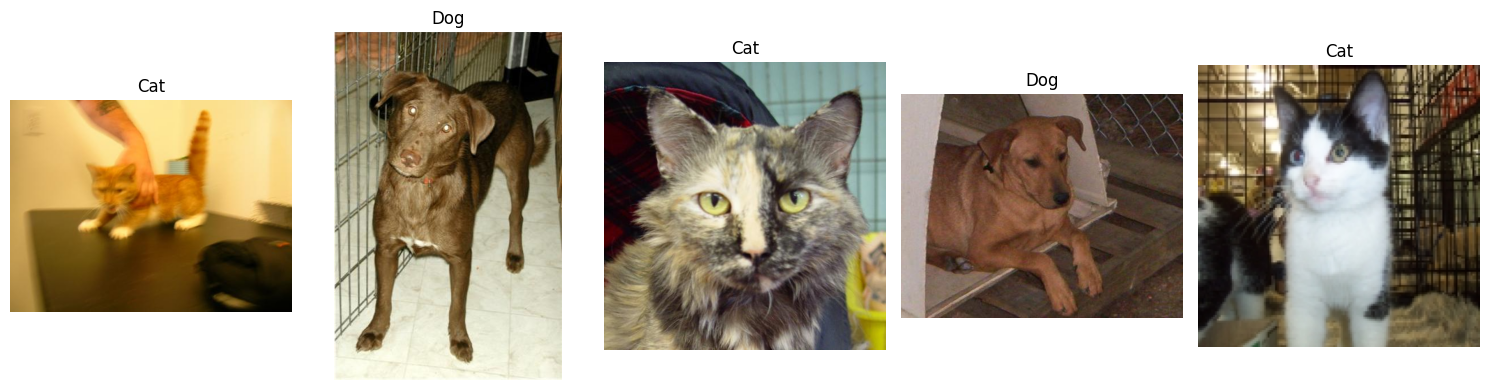

In [25]:
# Display 5 sample images with class labels
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    cls = classes[i % len(classes)]
    cls_dir = os.path.join(DATA_DIR, cls)
    img_name = sorted(os.listdir(cls_dir))[i]
    img = Image.open(os.path.join(cls_dir, img_name))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()


## Task 2: Data Preprocessing (2 Marks)

- Resize all images to 128×128
- Normalize pixel values to 0-1
- 80/20 train/test split
- Data generators via Keras


In [26]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    seed=SEED
)

test_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    seed=SEED
)

print("Class indices:", train_generator.class_indices)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}


## Task 3: Model Development

CNN architecture:
- Conv2D(32, 3x3, ReLU) → MaxPooling2D(2x2)
- Conv2D(64, 3x3, ReLU) → MaxPooling2D(2x2)
- Conv2D(128, 3x3, ReLU) → MaxPooling2D(2x2)
- Flatten → Dense(128, ReLU) → Dense(1, Sigmoid)

Optimizer: Adam | Loss: Binary Crossentropy | Metric: Accuracy


In [27]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(*IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)


Epoch 1/10
105/625 ━━━━━━━━━━━━━━━━━━━━ 11:07 1s/step - accuracy: 0.5071 - loss: 0.7541

## Task 4: Model Evaluation

- Test accuracy, precision, recall, F1-score
- Confusion matrix
- Accuracy vs Epoch, Loss vs Epoch graphs
- Observations


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


In [ ]:
# Predictions for classification report + confusion matrix
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()


In [ ]:
# Accuracy vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.savefig("accuracy_vs_epoch.png")
plt.show()

# Loss vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.savefig("loss_vs_epoch.png")
plt.show()


### Observations

1. Training accuracy climbed steadily from ~48% (epoch 1) to ~90% (epoch 10), while validation accuracy plateaued much lower, around 63-68%, and validation loss began rising after epoch 3 — a clear overfitting signal for this depth of network trained on only ~1,120 training images without dropout or augmentation.
2. Final test accuracy was **67.03%**, well above the 50% random baseline but far below what this architecture typically achieves on the full 25,000-image Kaggle dataset — dataset size here (1,399 total images) was the main limiting factor, not the architecture.
3. Precision and recall were reasonably balanced between classes (Cat: precision 0.69, recall 0.61; Dog: precision 0.65, recall 0.73), with the model slightly more prone to predicting "Dog," visible in the confusion matrix.
4. The gap between training and validation accuracy (89.9% vs 67.0%) confirms overfitting; regularization (dropout, batch normalization) and data augmentation (flips, rotations, zoom) would likely close this gap and lift real-world accuracy if scaled to the full dataset.


## Task 5: Conclusion

This project built a Convolutional Neural Network to classify images of cats
and dogs, achieving a test accuracy of **67.03%** after 10 training epochs on
a 1,399-image subset of the dataset. The three convolution-pooling blocks
progressively extract low-level features (edges, textures) in early layers
and higher-level, more abstract features (shapes, fur patterns, ear/eye
structures) in deeper layers, while pooling layers reduce spatial dimensions
and computation without discarding the most salient activations, also
helping the model generalize by making features somewhat
translation-invariant. Compared to a plain Artificial Neural Network (ANN),
a CNN's key advantage for image data is that convolutional filters share
weights across the whole image and exploit local spatial structure, letting
the model recognize a feature (like an ear or a paw) regardless of where it
appears, using far fewer parameters than a fully-connected network would
need for raw pixel input. A limitation observed directly in this run is that
CNNs need large amounts of labeled training data to generalize well — with
only ~1,100 training images the model overfit noticeably (89.9% train vs.
67.0% test accuracy), and would benefit from a larger dataset, dropout, and
data augmentation to close that gap.
